<a href="https://colab.research.google.com/github/ankxie/PHYS620/blob/main/Book/L06-MeanMolecularWeight/06-MeanMolecularWeight-template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook <font color='purple'>06-MeanMolecularWeight</font> (template)

We start by importing the modules
* Numpy -- operations on arrays and matrixes (and pi)
* Matplotlib pyplot -- plotting library
* Astropy units -- defined quantities with units. We also import the CDS conversions

In [4]:
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline
from astropy import constants as const
import astropy.units as u
from astropy.units import cds
cds.enable()

## 1. In class: Solar abundances

In the 06-Grevesse.txt file, you will find a tabulation of the solar abundances for the first 30 elements that looks like this:

<div style="width:600px;height:200px;padding:2px;border:1px dotted black;">
<PRE>
# Abundance from Grevesse
Z   A       Element   NumberFraction    logAbund    X
1   1.0079  H         1.00E+00          1.20E+01    7.04E-01
2   4.0026  He        1.00E-01          1.10E+01    2.80E-01
3   6.941   Li        1.26E-11          1.10E+00    6.10E-11
4   9.0122  Be        2.51E-11          1.40E+00    1.58E-10
....
</PRE>
</div>

### a. We will first learn how to read in a data file, using a Numpy function

In [4]:
dtype="i8,f8,|U8,f8,f8,f8"
# If using "S8" for the element string,
# numpy will use bytestring, which need to be decoded
# before using in mathplotlib -- using U8 here instead
url = 'https://raw.githubusercontent.com/veropetit/PHYS633-F2026/main/Book/L06-MeanMolecularWeight/06-Grevesse.txt'
#---------------------------------------
#---------------------------------------
# In class

# How to read a data file

AbundSolar = np.genfromtxt(url, skip_header= 1, names = True, dtype = dtype)

print(AbundSolar['Element'])


['H' 'He' 'Li' 'Be' 'B' 'C' 'N' 'O' 'F' 'Ne' 'Na' 'Mg' 'Al' 'Si' 'P' 'S'
 'Cl' 'Ar' 'K' 'Ca' 'Sc' 'Ti' 'V' 'Cr' 'Mn' 'Fe' 'Co' 'Ni' 'Cu' 'Zn']


### b. Now let's see what the abundance pattern looks like

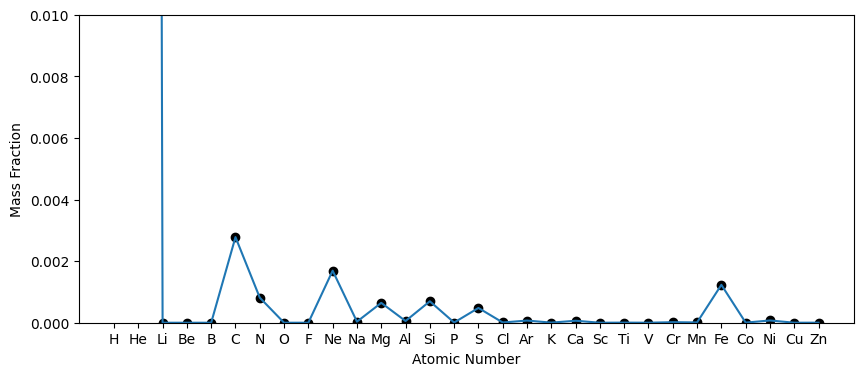

In [12]:
fig, ax = plt.subplots(1,1, figsize=(10,4))
ax.set_ylim(0,0.01)

#---------------------------------------
#---------------------------------------
# In class

ax.plot(AbundSolar['Z'], AbundSolar['X'])
ax.scatter(AbundSolar['Z'], AbundSolar['X'], color = 'k')


# We can set the labels in the plots to the name of the elements!

ax.set_ylabel('Mass Fraction')
ax.set_xlabel('Atomic Number')
_ = ax.set_xticks(AbundSolar['Z'])
_ = ax.set_xticklabels(AbundSolar['Element'])


> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

The plot of Mass Fraction vs Atomic number for the Sun shows that the abundances are not smooth. H and He have a much higher abundance than the other elements.

## 2. In class: what is the mean molecular weight for solar abundance?

Let's calculate the value for the mean molecular weight using the $X_i$ in our abundance table.

We found that:

$$\frac{1}{\mu} = \frac{1}{\mu_\mathrm{ion}} + \frac{1}{\mu_\mathrm{e}},$$
with

$$\frac{1}{\mu_\mathrm{ion}} = \sum_i \frac{X_i}{A_i}$$

and

$$\frac{1}{\mu_\mathrm{e}} = \sum_i \frac{Z_i X_i}{A_i} y_i $$

Let's consider two cases:


### a. The gas is completely neutral

> **TODO**: write a few words about how the equations above can be simplified for a completely neutral gas

If the gas is completely neutral, then $\mu_e → ∞$, therefore $\frac{1}{\mu_e} = 0$. So, we can simplify the above equations to $\mu = \mu_{ion}$

### b. The gas is completely ionized

> **TODO**: write a few words about how the equations above can be simplified for a completely ionized gas

If the gas is completely ionized, then $y_i = 1$ for all elements, and $\frac{1}{\mu_\mathrm{e}} = \sum_i \frac{Z_i X_i}{A_i}$. Therefore, $\frac{1}{\mu} = \sum_i \frac{(1+Z_i)X_i}{A_i}$


### c. In class calculation of the mean molecular weigth for the Sun (assuming completely neutral and completely ionized)

In [15]:
#---------------------------------------
#---------------------------------------
# In class

mu_ion = 1/np.sum(AbundSolar['X']/AbundSolar['A'])

mu_e = 1/np.sum(AbundSolar['Z'] * AbundSolar['X'] / AbundSolar['A'])

mu_ionizedgas = 1/ (1/mu_ion + 1/mu_e)

print("For a completely neutral gas, the mean molecular weight for the Sun is", mu_ion)
print("For a completely ionized gas, the mean molecular weight for the Sun is", mu_ionizedgas)


For a completely neutral gas, the mean molecular weight for the Sun is 1.3005465793861997
For a completely ionized gas, the mean molecular weight for the Sun is 0.6205107952580795


> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

Whether or not a gas is ionized affects its mean molecular weight. The values for the mean molecular mass of the Sun that I calculated make sense. The Sun is 70% hydrogen and 28% helium, so we expect its mean molecular weight to be slightly above 1 if it was neutral. If the Sun was completely ionized, then it would have slightly more than 2 times the number of free particles, so its mean molecualr mass would be halved.

## 3. At home: What will $\mu$ be at the center of the Sun once all the H is converted into He?

> **TODO**: Make a calulation of the mean molecular weight in the core of the Sun, once all of the hydrogen has been converted into helium (remember, at the surface of the Sun where there is no nuclear reactions: $X$=70%, $Y$=28%, and $Z$=2%)
>
> You can use the approximations I gave in the last slide of the PDF class notes
>
> You can use the code cell below as a calculator, or you can do the calculation by hand.

In [2]:
#---------------------------------------
#---------------------------------------
# At home

X = 0 #once all the hydrogen has been converted into helium, its mass fraction is 0
Y = .98
Z = .02

#equations from the last slide of the class notes

mu_neutral = 1/ (X + Y/4)
mu_ionized = 2/(3*X + Y/2 + 1)

print("For a completely neutral gas, the mean molecular weight for the Sun is", mu_neutral)
print("For a completely ionized gas, the mean molecular weight for the Sun is", mu_ionized)


For a completely neutral gas, the mean molecular weight for the Sun is 4.081632653061225
For a completely ionized gas, the mean molecular weight for the Sun is 1.342281879194631


> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

If the Sun was mostly composed of neutral hydrogen, then we would expect its mean molecular mass to be slightly higher than the mean molecular mass of neutral helium gas. This is the result I obtained. If the Sun was mostly composed of ionized helium, then the same amount of mass would be "shared" amongst 3 free particles. Therefore, we would expect a mean molecular mass around 4/3, which is the result I obtained.

These results show that once all of the H in the Sun is converted into He, then its mean molecular mass will increase. This has implications for its strucure, since to maintain hydrostatic equilibrium when $\mu$ changes, some combination of $P(r), \rho(r),$ and $T(r)$ will have to change.

## 4. At home: Finally, let's check what the mean molecular weight looks like inside of the sun

### a. Let's use the MESA model to look at $\mu$ as a function of radius inside of the Sun.

> **TODO**: Based on the MESA model for the Sun, I provide an array `mu` that contains the mean molecular weigth. Create a plot of the mean molecular weight as a function of $r/R_\star$. The corresponding array for the $r/R_\star$ is called `r_rs`

### b. In the interpretation, explain the shape of the curve

You might find it interesting to look at the variation of the temperature `data['logT']` to help you with your interpretation -- you might find it enlightening!


Text(0.5, 0, '$r/R_\\star$')

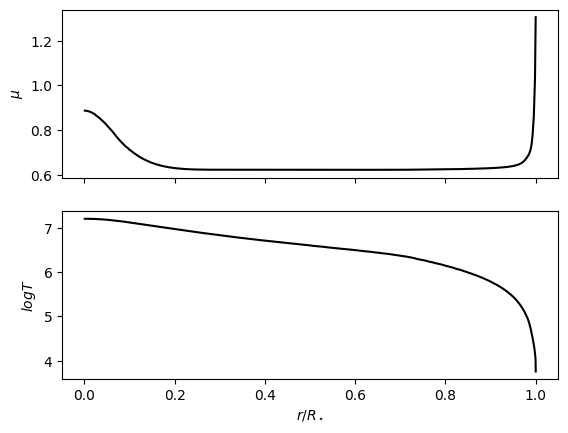

In [15]:
def read_model(file):
    # Here's a function that reads it the MESA model.
    cols = np.array([1,2,3,4,5,9,29,66])-1
    return np.genfromtxt(file, skip_header=5, names=True, usecols = cols)
# Reading the model
data = read_model('https://raw.githubusercontent.com/veropetit/PHYS633-F2026/main/Book/L06-MeanMolecularWeight/06-MESAdatafile.txt')

# Calculating mu using the density (in cgs), the temperature (in K) and the gas pressure
mu = 10**data['logRho'] * u.g / u.cm**3 * const.k_B * 10**data['logT'] * u.K / (10**data['logPgas']*u.Ba) / const.u
mu = mu.decompose() # Should be unitless.

r_rs = 10**(data['logR']-data['logR'][0])

#---------------------------------------
#---------------------------------------
# At home

fig, ax = plt.subplots(2, sharex = True)

ax[0].plot(r_rs, mu, color = 'k')
ax[0].set_ylabel(r'$\mu$')

ax[1].plot(r_rs, data['logT'], color = 'k')
ax[1].set_ylabel(r'$logT$')
ax[1].set_xlabel(r'$r/R_\star$')


> **TODO**: Please write a small paragraph with an interpretation of the result obtained:

This plot of $\mu$ vs $r/R_{star}$ makes sense considering what we already know about the structure of the Sun and the plot of $logT$ vs $r/R_{star}$. We know that the core of the Sun is the site of nuclear reactions, so it makes sense that $\mu$ increases towards the center of the Sun. Then, the middle portion of the Sun is ionized (which makes sense when we look at the temperature of that section), so we would expect $\mu$ to be around 0.62. This is the value for an ionized gas with solar abundances that we found in 2c. As the Sun rapidly cools at its edge, electrons recombine with ions, and $\mu$ rapidly increases.


## 5. Reading assignement: "what can we measure about stars" -- part 3
In this graduate course, we are making an advanced physical and mathematical model of star.

But it is still good to learn and/or remind ourselves about which physical characteristics of stars we can actually measure. You might have covered some of this in some details in previous physics or astro courses (at UD PHYS 133, 144, 333, or 469) -- but it is still a good idea to have a quick look at the suggested reading below before crafting your paragraph.

One other thing that can be measured is the composition of a star's surface.

> **TODO**: Have a look at section 5.3 Spectroscopy in Astronomy, 5.4
The Structure of the Atom and/or 5.5 Formation of Spectral Lines of the Open Stack Astronomy online [textbook](https://openstax.org/books/astronomy/pages/5-2-the-electromagnetic-spectrum), and write a short conceptual paragraph about how astronomer can determine the composition of stars through spectra.

Gas absorbs and emits discrete wavelengths of light depending on its chemical composition. A cool, thin gas absorbs certain wavelengths of light when a continuous spectrum is shone through it. This creates an absorption spectrum. A hot, thin gas will emit discrete wavelengths of light. This creates an emission spectrum. Atoms are able to absorb and emit light due to electron energy levels. When they absorb light, that energy is transfered to the electron, raising its energy. Conversely, if the electron goes down in energy, that change in energy becomes light. These energy levels are discrete, so there is a finite set of energies a bound electron can absorb or emit. Each element and molecule has a unique pattern of spectral lines because they have unique electron energy level structures. Therefore, by analyzing the absorption and emission lines of a spectrum, we can determine the composition of its source.